In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import NullFormatter
from setup_plot import setup_plot

setup_plot()
fontsize = 8

In [92]:
val_R = [None] * 6
val_Q = [None] * 6
pdf = [None] * 6

for i in range(6):
    with np.load(f"data/3D/RQ_joint_pdf_N={2**(i+5)}.npz") as data:
        val_R[i] = data["val_R_star"]
        val_Q[i] = data["val_Q_star"]
        pdf[i] = data["pdf_star"]

print("R-Q joint PDF loaded successfully.")

val_R = np.array(val_R)
val_Q = np.array(val_Q)
pdf = np.array(pdf)

for i in range(6):
    print(np.amax(pdf[i, :]), np.amin(pdf[i, :]))

sigma_A = [2.58620872e+01, 6.97103464e+01, 1.20187417e+02, 1.65743906e+02, 2.05329434e+02, 2.38592158e+02]

R-Q joint PDF loaded successfully.
4.446442681172205 0.0
5.585361134676319 0.0
0.10767469350948393 0.0
0.007375328208842395 0.0
1.2606304676840387e-05 0.0
2.1264488225721398e-06 0.0


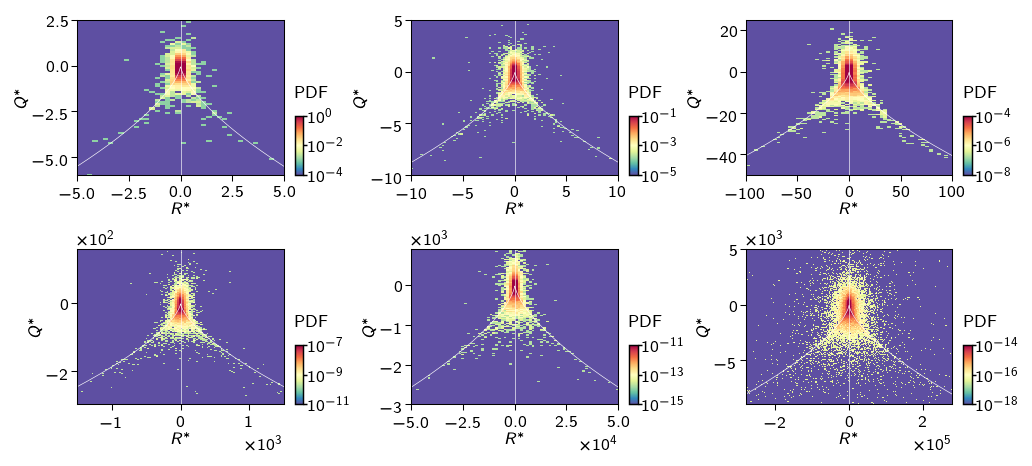

In [96]:
fig_width = 18 / 2.54
fig_height = 18 / 2.54

fig = plt.figure(figsize=(fig_width, fig_height))
ax_width = 3.5 / 2.54 / fig_width
ax_height = ax_width / 4 * 3
cbar_length = 1 / 2.54 / fig_width
cbar_width = 1.2 / 8 / 2.54 / fig_width

def mapping(i):
    return (i, 0) if i < 3 else (i - 3, -1)

xm = np.array([5, 1e1, 1e2, 1.5e3, 5e4, 2.8e5])
y1 = np.array([-6, -10, -50, -3e2, -3e3, -0.9e4])
y2 = np.array([2.5, 5, 25, 1.6e2, 0.9e3, 0.5e4])
vmin = np.array([-4, -5, -8, -10.4, -14, -16])
vmax = np.array([0, -1, -4, -6.4, -10, -12])
cmap_tick = [[r"$10^{-4}$", r"$10^{-2}$", r"$10^{0}$"], 
             [r"$10^{-5}$", r"$10^{-3}$", r"$10^{-1}$"], 
             [r"$10^{-8}$", r"$10^{-6}$", r"$10^{-4}$"], 
             [r"$10^{-11}$", r"$10^{-9}$", r"$10^{-7}$"], 
             [r"$10^{-15}$", r"$10^{-13}$", r"$10^{-11}$"], 
             [r"$10^{-18}$", r"$10^{-16}$", r"$10^{-14}$"]]

for i in range(6): 
    ax = fig.add_axes([mapping(i)[0] * (ax_width + 0.12), mapping(i)[1] * (ax_height + 0.07), ax_width, ax_height])

    R, Q = np.meshgrid(val_R[i, :], val_Q[i, :], indexing="ij")
    ax.pcolormesh(
        R,
        Q,
        np.log10(pdf[i, :] + 1e-100),
        cmap="Spectral_r",
        vmin=vmin[i],
        vmax=vmax[i],
        rasterized=True,
    )
    ax.axvline(x=0, linewidth=0.3, color="white")
    R0 = np.linspace(np.amin(R), np.amax(R), 3000)
    ax.plot(R0, -3 * (R0**2 / 4) ** (1 / 3), linewidth=0.3, color="white")

    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 3), useOffset=False, useMathText=True)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 2), useOffset=False, useMathText=True)

    ax.set_xlim(-xm[i], xm[i])
    ax.set_ylim(y1[i], y2[i])
    plt.xlabel(r"$R^*$", labelpad=1, size=8)
    plt.ylabel(r"$Q^*$", labelpad=1, size=8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
    ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
    ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)

    cax = fig.add_axes([ax_width + 0.01 + mapping(i)[0] * (ax_width + 0.12), mapping(i)[1] * (ax_height + 0.07), cbar_width, cbar_length])
    cbar = plt.colorbar(
        mpl.cm.ScalarMappable(mpl.colors.Normalize(vmin=0, vmax=1), "Spectral_r"),
        ax=ax,
        cax=cax,
        orientation="vertical",
        ticks=[0, 0.5, 1],
        location="right",
    )
    cbar.set_ticklabels(cmap_tick[i])
    cax.text(2, 1.4, r"PDF", ha="center", va="center")
    cbar.ax.tick_params(length=2, width=0.7, labelsize=8, pad=0)
    cbar.outline.set_linewidth(0.7)

# 
plt.savefig(fr'figures/RQ_encode.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')